# 04. Визуализация результатов

Все графики проекта в одном месте: от сырых данных до финальных рекомендаций.  
Данные: объединённый датасет df1+df2 (427k записей, 1735 скважин), GMM k=8.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import GradientBoostingRegressor
import warnings, gc
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

COLORS = ['#22c55e', '#84cc16', '#eab308', '#f59e0b', '#ef4444', '#dc2626', '#7c3aed', '#0ea5e9']
FEATURES = ['pressure_axis', 'pressure_rotation']
RANDOM_STATE = 42

## Загрузка данных

In [ ]:
df = pd.read_csv('clustered.csv')
N_CLUSTERS = df['cluster'].nunique()

# Загрузка моделей и результатов из 03_modeling
import pickle, os
if os.path.exists('models_gmm.pkl'):
    with open('models_gmm.pkl', 'rb') as f:
        saved = pickle.load(f)
    models = saved['models']
    cv_scores = saved['cv_scores']
    opt_results = saved['optimization']
    print('Модели и результаты загружены из models_gmm.pkl')
else:
    # Если pkl нет — обучаем на месте
    from sklearn.model_selection import GroupKFold
    models = {}; cv_scores = {}; opt_results = []
    gkf = GroupKFold(n_splits=5)
    for c in range(N_CLUSTERS):
        sub = df[df['cluster']==c]
        X, y = sub[FEATURES].values, sub['speed'].values
        groups = sub['well_id'].values
        gbm = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
        if sub['well_id'].nunique() >= 5:
            from sklearn.model_selection import cross_val_score
            scores = cross_val_score(gbm, X, y, cv=gkf, groups=groups, scoring='r2')
            cv_scores[c] = scores.mean()
        else:
            cv_scores[c] = float('nan')
        gbm.fit(X, y)
        models[c] = gbm
        # Best operators
        q75 = sub['speed'].quantile(0.75)
        top25 = sub[sub['speed'] >= q75]
        opt_results.append({
            'cluster': c, 'R2_cv': cv_scores[c],
            'fi_Pax': gbm.feature_importances_[0], 'fi_Prot': gbm.feature_importances_[1],
            'current_v': y.mean(), 'n_records': len(sub),
            'current_Pax': sub['pressure_axis'].median(), 'current_Prot': sub['pressure_rotation'].median(),
            'best_v': top25['speed'].mean(), 'best_gain': (top25['speed'].mean() - y.mean()) / y.mean() * 100,
            'best_Pax': top25['pressure_axis'].median(), 'best_Prot': top25['pressure_rotation'].median(),
        })
        del gbm; gc.collect()
    print('Модели обучены на месте')

if 'cluster_prob' not in df.columns:
    gm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE, n_init=5)
    gm.fit(df[['log_EI']].values)
    df['cluster_prob'] = gm.predict_proba(df[['log_EI']].values).max(axis=1)

print(f'Данные: {len(df)} строк, {df["well_id"].nunique()} скважин, {N_CLUSTERS} кластеров')

Модели загружены из models_gmm.pkl
Данные: 427200 строк, 1735 скважин, 8 кластеров


---
## 1. Распределения исходных переменных

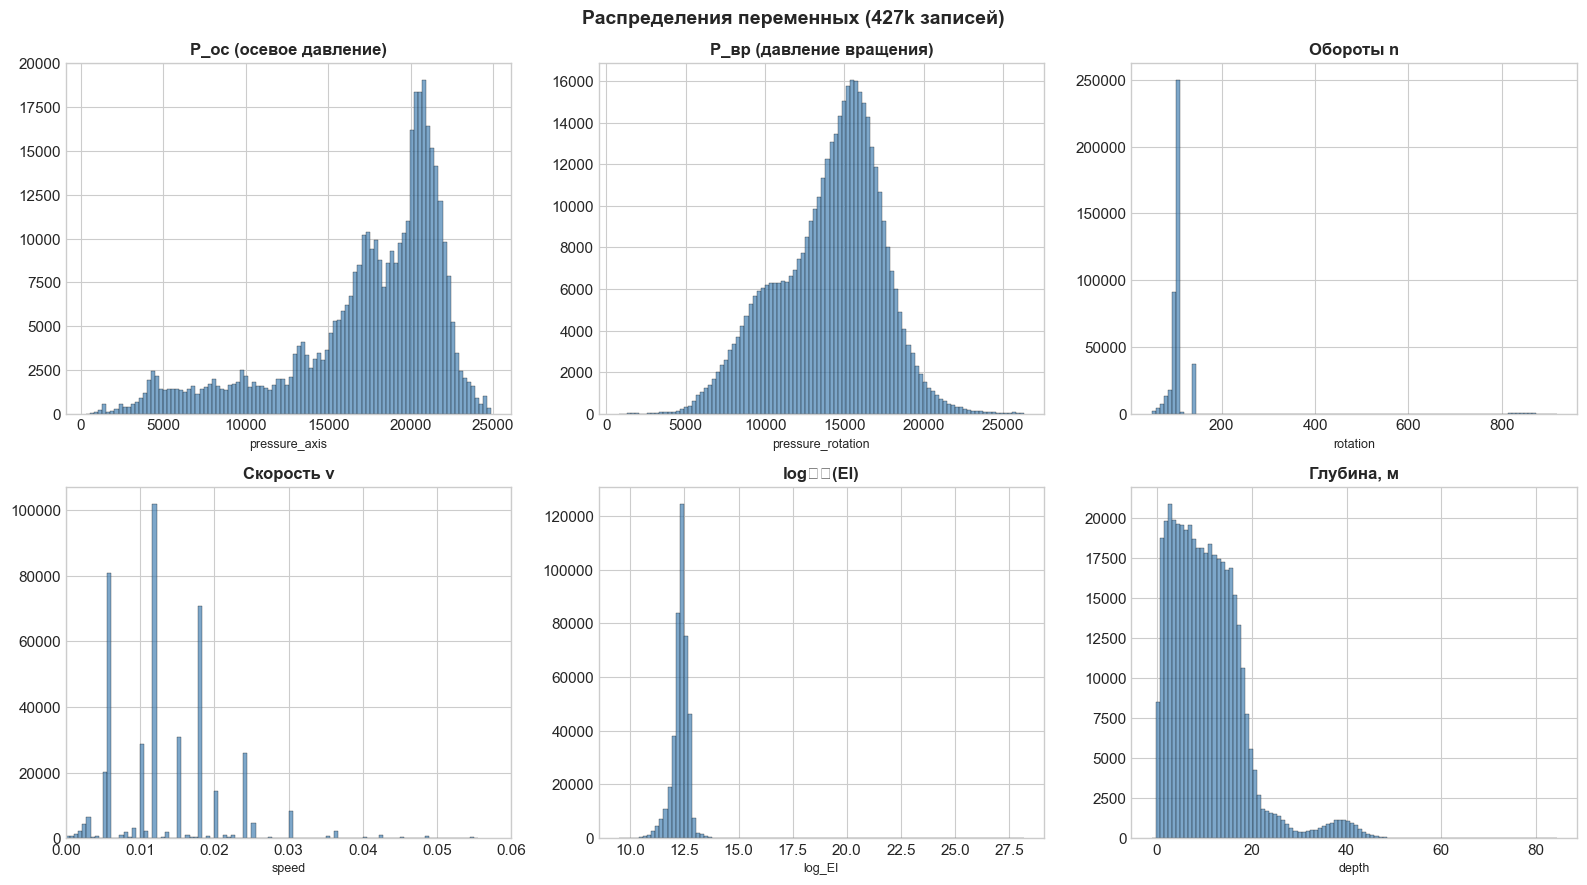

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_info = [
    ('pressure_axis', 'P_ос (осевое давление)', None),
    ('pressure_rotation', 'P_вр (давление вращения)', None),
    ('rotation', 'Обороты n', None),
    ('speed', 'Скорость v', (0, 0.06)),
    ('log_EI', 'log₁₀(EI)', (9, 15)),
    ('depth', 'Глубина, м', None),
]

for ax, (col, title, xlim) in zip(axes.flat, plot_info):
    data = df[col]
    if xlim:
        data = data[(data >= xlim[0]) & (data <= xlim[1])]
    ax.hist(data, bins=100, edgecolor='black', linewidth=0.3, alpha=0.7, color='steelblue')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    if xlim:
        ax.set_xlim(xlim)

plt.suptitle('Распределения переменных (427k записей)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Матрица корреляций

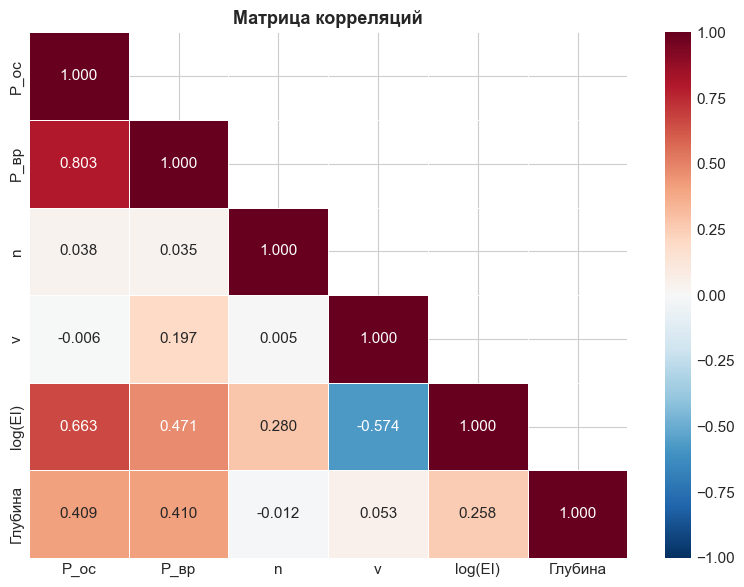

In [4]:
corr_cols = ['pressure_axis', 'pressure_rotation', 'rotation', 'speed', 'log_EI', 'depth']
corr_labels = ['P_ос', 'P_вр', 'n', 'v', 'log(EI)', 'Глубина']

fig, ax = plt.subplots(figsize=(8, 6))
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            xticklabels=corr_labels, yticklabels=corr_labels, ax=ax,
            vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Матрица корреляций', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. df1 vs df2 — сравнение датасетов

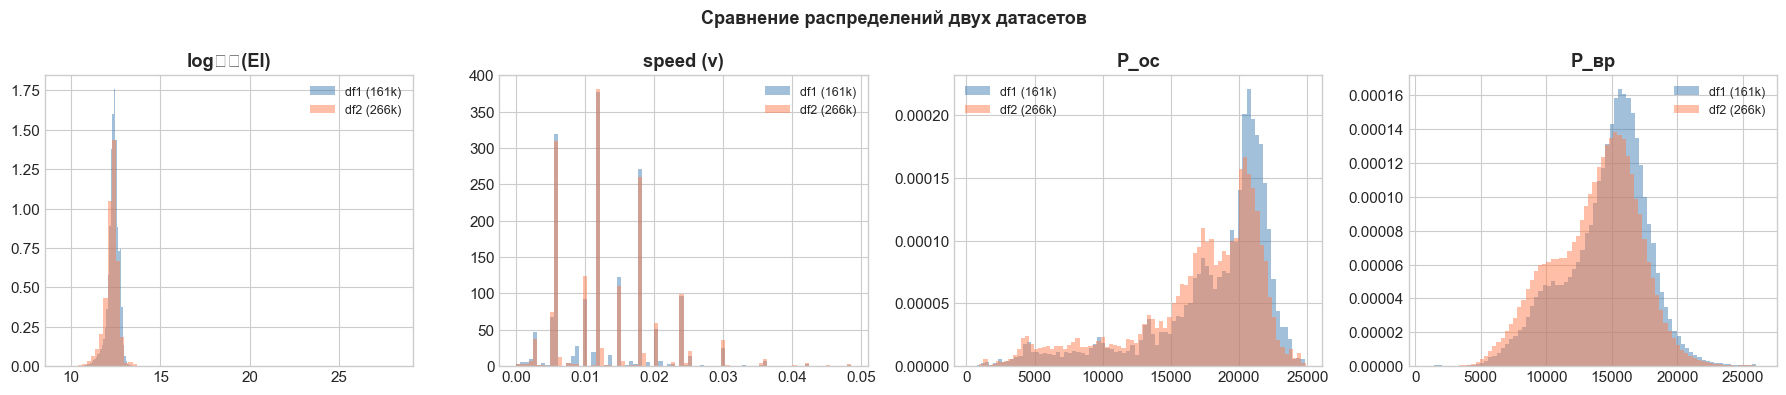

In [5]:
if 'source' not in df.columns:
    print('Столбец source отсутствует — график df1 vs df2 пропущен')
else:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, col, title, xlim in zip(axes,
        ['log_EI', 'speed', 'pressure_axis', 'pressure_rotation'],
        ['log₁₀(EI)', 'speed (v)', 'P_ос', 'P_вр'],
        [None, (0, 0.05), None, None]):
        d1 = df[df['source']=='df1'][col]
        d2 = df[df['source']=='df2'][col]
        if xlim:
            d1 = d1[(d1 >= xlim[0]) & (d1 <= xlim[1])]
            d2 = d2[(d2 >= xlim[0]) & (d2 <= xlim[1])]
        ax.hist(d1, bins=80, alpha=0.5, density=True, label=f'df1 ({len(df[df["source"]=="df1"])/1000:.0f}k)', color='steelblue')
        ax.hist(d2, bins=80, alpha=0.5, density=True, label=f'df2 ({len(df[df["source"]=="df2"])/1000:.0f}k)', color='coral')
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=9)
    plt.suptitle('Сравнение распределений двух датасетов', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Кластеры — гистограмма log₁₀(EI)

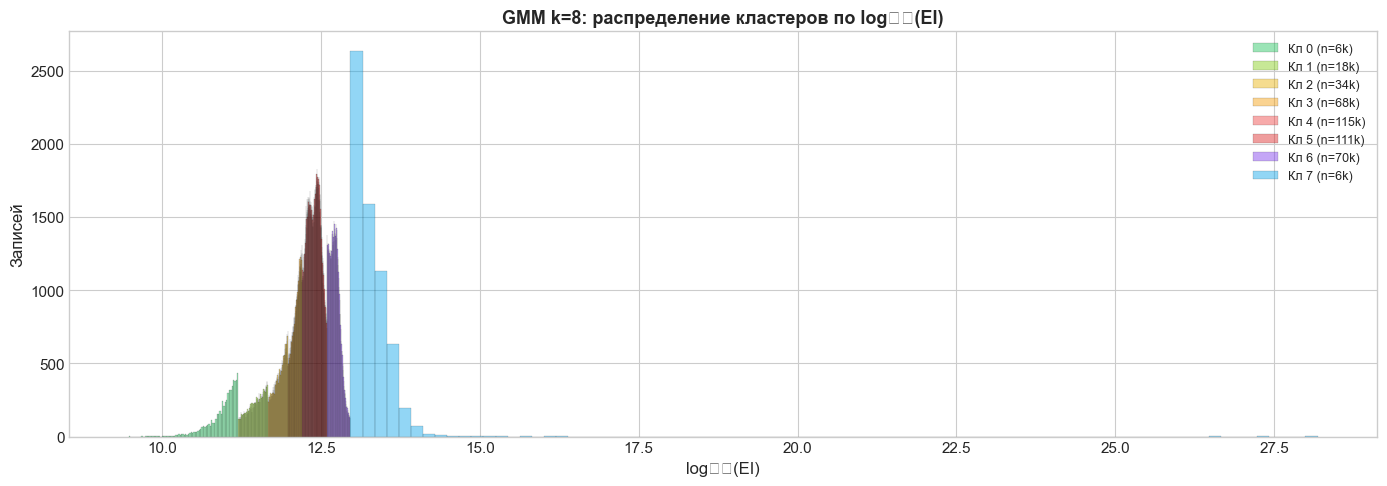

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
for c in range(N_CLUSTERS):
    s = df[df['cluster']==c]
    ax.hist(s['log_EI'], bins=80, alpha=0.45, color=COLORS[c],
            edgecolor='black', linewidth=0.2, label=f'Кл {c} (n={len(s)/1000:.0f}k)')
ax.set_xlabel('log₁₀(EI)', fontsize=12)
ax.set_ylabel('Записей', fontsize=12)
ax.set_title('GMM k=8: распределение кластеров по log₁₀(EI)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Кластеры по глубине (примеры скважин)

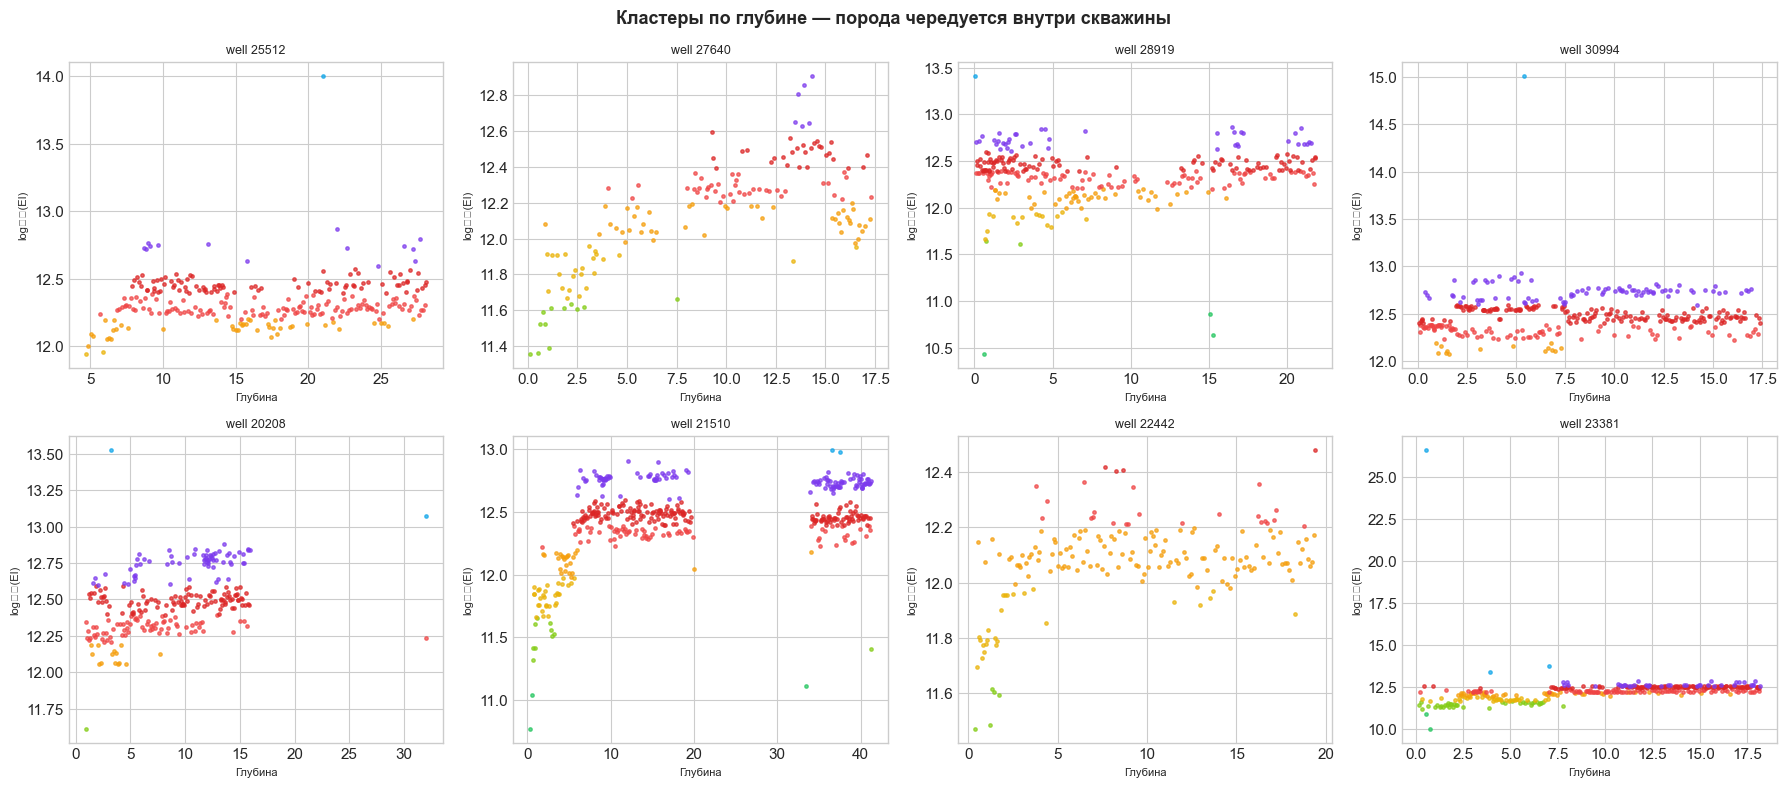

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
sample_wells = df['well_id'].unique()[::200][:8]  # равномерно по well_id

for ax, wid in zip(axes.flat, sample_wells):
    w = df[df['well_id']==wid].sort_values('depth')
    for c in range(N_CLUSTERS):
        wc = w[w['cluster']==c]
        if len(wc) > 0:
            ax.scatter(wc['depth'], wc['log_EI'], s=6, alpha=0.7, color=COLORS[c])
    ax.set_title(f'well {wid}', fontsize=9)
    ax.set_xlabel('Глубина', fontsize=8)
    ax.set_ylabel('log₁₀(EI)', fontsize=8)

plt.suptitle('Кластеры по глубине — порода чередуется внутри скважины', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Уверенность GMM (cluster probability)

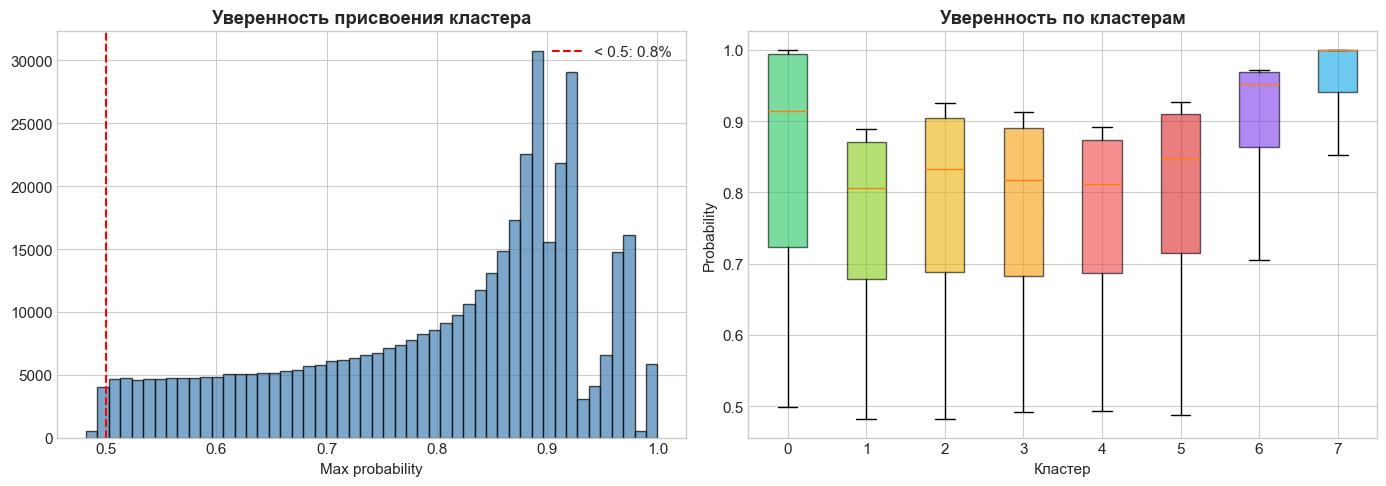

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['cluster_prob'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0.5, color='red', linestyle='--', label=f'< 0.5: {(df["cluster_prob"]<0.5).mean()*100:.1f}%')
axes[0].set_xlabel('Max probability')
axes[0].set_title('Уверенность присвоения кластера', fontweight='bold')
axes[0].legend()

# Prob by cluster
bp = axes[1].boxplot([df[df['cluster']==c]['cluster_prob'].values for c in range(N_CLUSTERS)],
                     labels=[str(c) for c in range(N_CLUSTERS)], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Probability')
axes[1].set_title('Уверенность по кластерам', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. Кривые насыщения: скорость vs P_вр по кластерам

**Главный график проекта.** Показывает как скорость растёт с давлением вращения  
и где наступает насыщение. Для каждого кластера — свой «потолок».

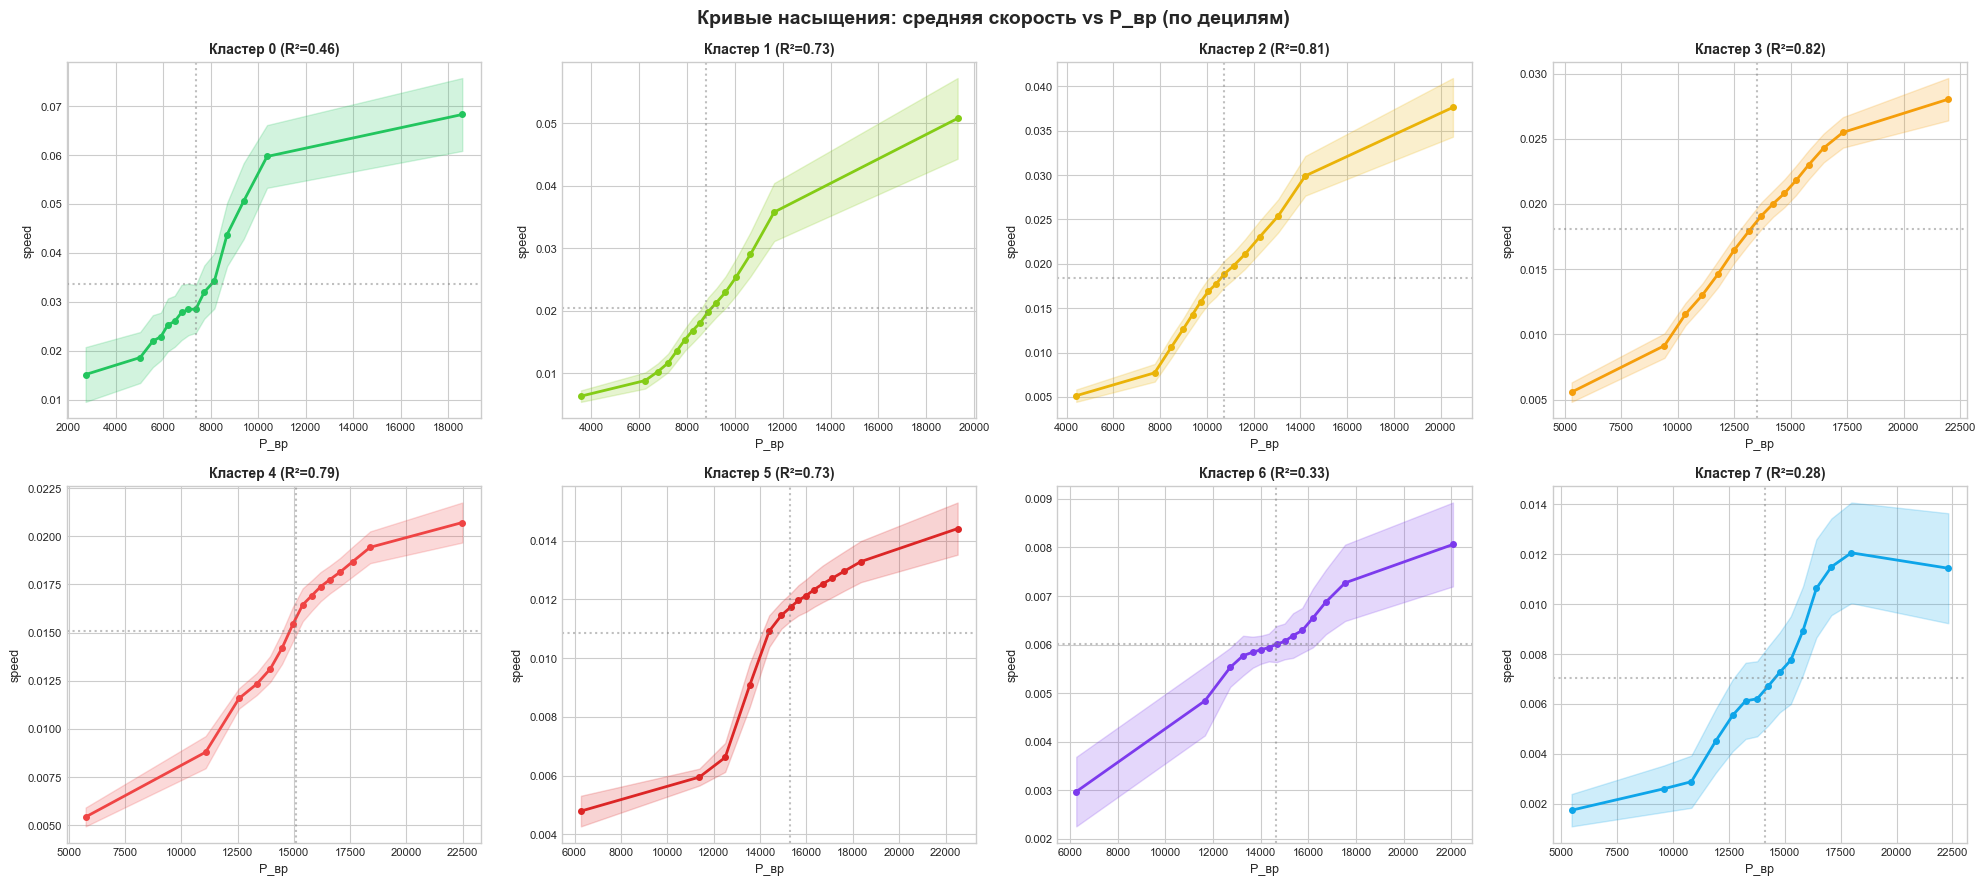

Серые линии = текущее среднее значение P_вр и speed
Тень = ±0.3 std


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    sub = df[df['cluster']==c].copy()
    
    # Binned means
    sub['pr_bin'] = pd.qcut(sub['pressure_rotation'], 15, duplicates='drop')
    grouped = sub.groupby('pr_bin')['speed'].agg(['mean', 'std', 'count'])
    grouped['mid'] = grouped.index.map(lambda x: x.mid)
    grouped = grouped.sort_values('mid')
    
    ax.plot(grouped['mid'], grouped['mean'], 'o-', color=COLORS[c], markersize=4, linewidth=2)
    ax.fill_between(grouped['mid'],
                    grouped['mean'] - grouped['std']*0.3,
                    grouped['mean'] + grouped['std']*0.3,
                    alpha=0.2, color=COLORS[c])
    
    # Current average
    ax.axhline(sub['speed'].mean(), color='gray', linestyle=':', alpha=0.5)
    ax.axvline(sub['pressure_rotation'].mean(), color='gray', linestyle=':', alpha=0.5)
    
    ax.set_title(f'Кластер {c} (R²={cv_scores[c]:.2f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('P_вр', fontsize=9)
    ax.set_ylabel('speed', fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle('Кривые насыщения: средняя скорость vs P_вр (по децилям)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Серые линии = текущее среднее значение P_вр и speed')
print('Тень = ±0.3 std')

## 8. Аналогичные кривые для P_ос

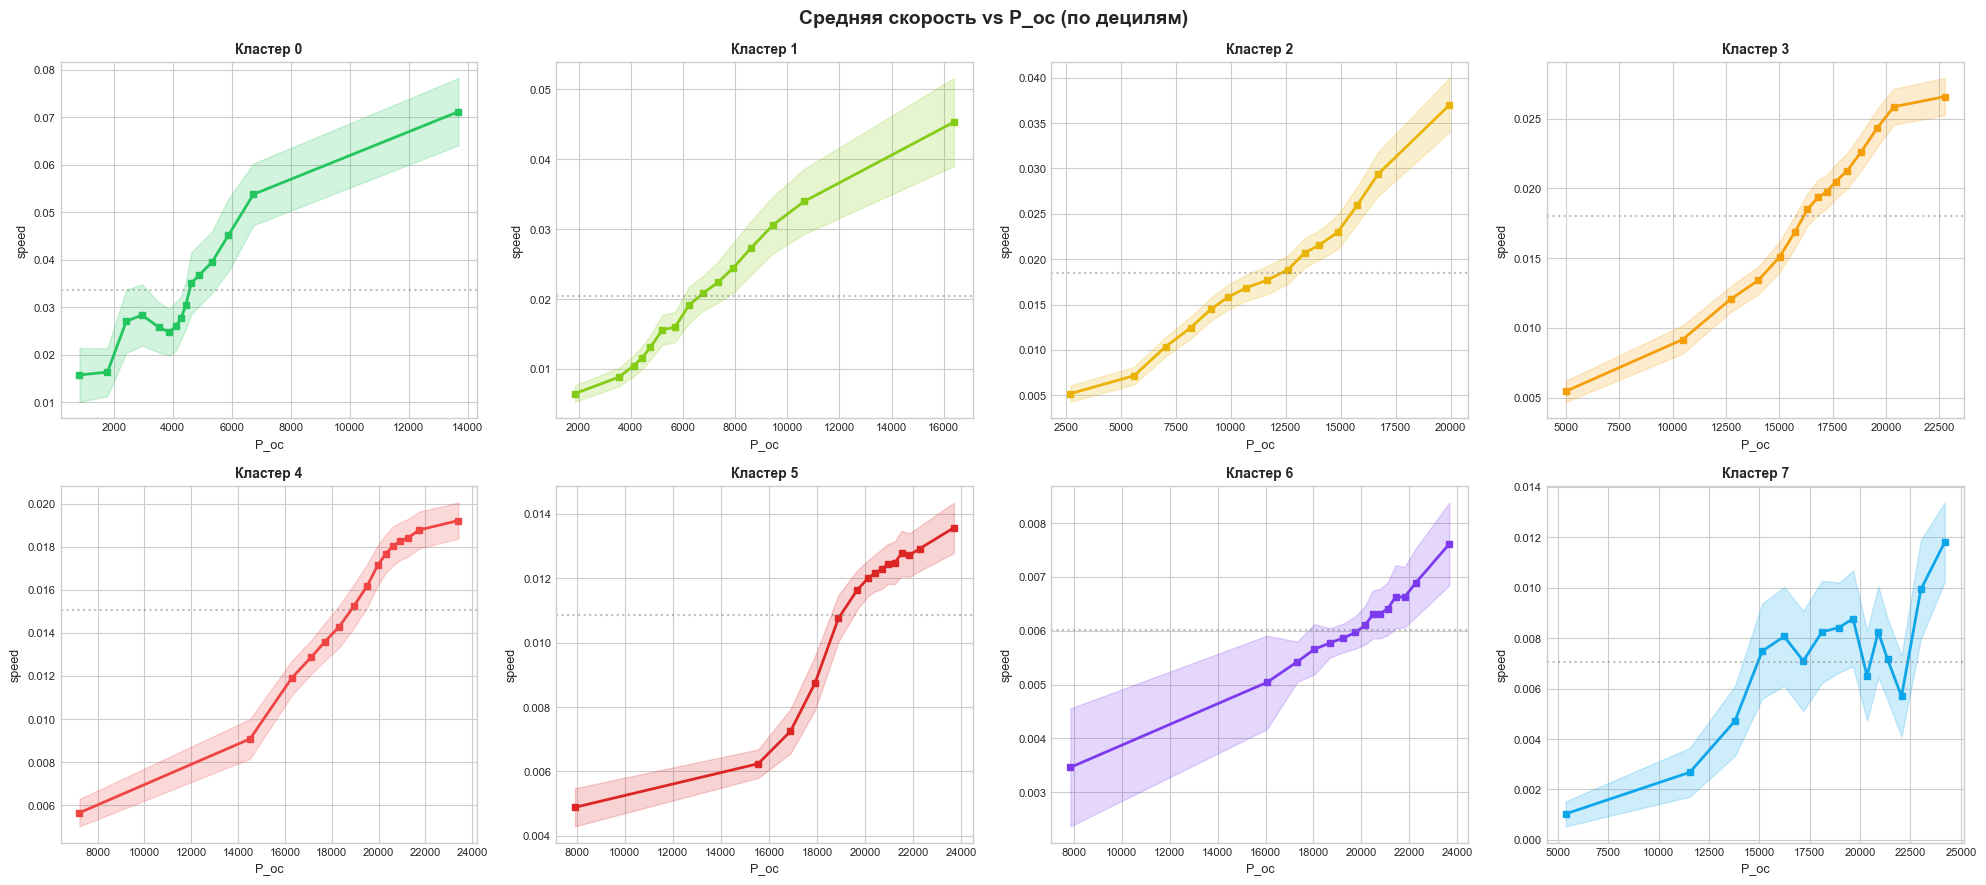

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    sub = df[df['cluster']==c].copy()
    sub['pa_bin'] = pd.qcut(sub['pressure_axis'], 15, duplicates='drop')
    grouped = sub.groupby('pa_bin')['speed'].agg(['mean', 'std'])
    grouped['mid'] = grouped.index.map(lambda x: x.mid)
    grouped = grouped.sort_values('mid')
    
    ax.plot(grouped['mid'], grouped['mean'], 's-', color=COLORS[c], markersize=4, linewidth=2)
    ax.fill_between(grouped['mid'],
                    grouped['mean'] - grouped['std']*0.3,
                    grouped['mean'] + grouped['std']*0.3,
                    alpha=0.2, color=COLORS[c])
    ax.axhline(sub['speed'].mean(), color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'Кластер {c}', fontsize=10, fontweight='bold')
    ax.set_xlabel('P_ос', fontsize=9)
    ax.set_ylabel('speed', fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle('Средняя скорость vs P_ос (по децилям)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. R² и Feature Importance по кластерам

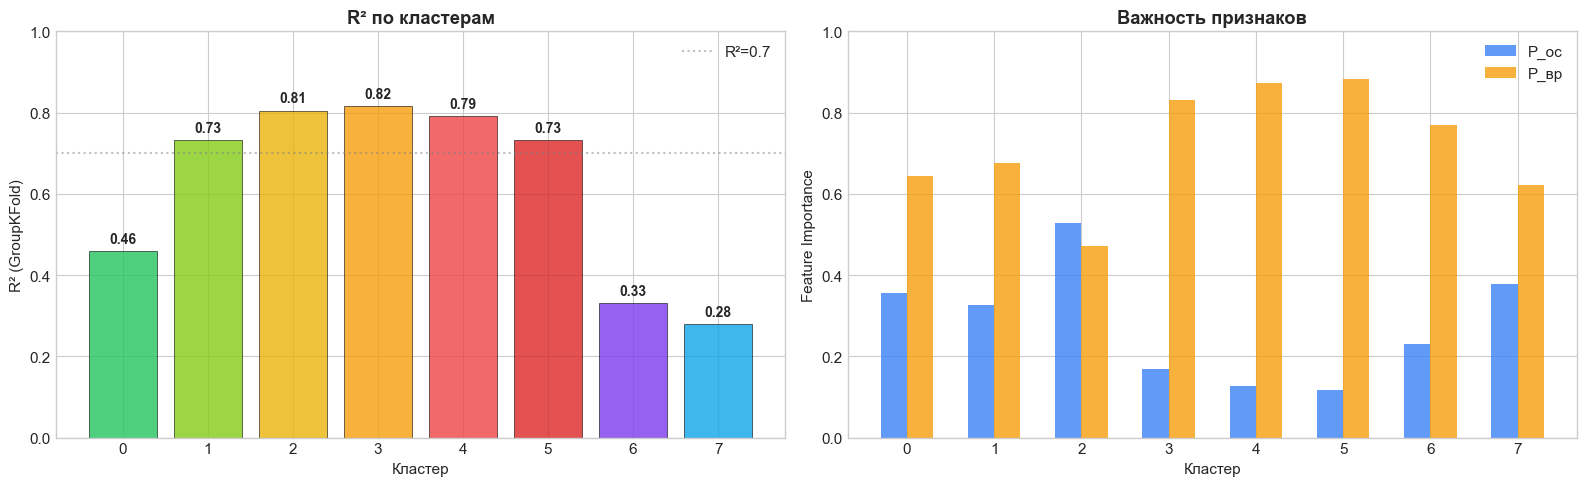

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(N_CLUSTERS)

# R²
r2_vals = [cv_scores[c] for c in range(N_CLUSTERS)]
bars = axes[0].bar(x, r2_vals, color=COLORS, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].axhline(0.7, color='gray', linestyle=':', alpha=0.5, label='R²=0.7')
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.2f}',
                ha='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Кластер'); axes[0].set_ylabel('R² (GroupKFold)')
axes[0].set_title('R² по кластерам', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_ylim(0, 1); axes[0].legend()

# Feature importance
fi_pa = [models[c].feature_importances_[0] for c in range(N_CLUSTERS)]
fi_pr = [models[c].feature_importances_[1] for c in range(N_CLUSTERS)]
axes[1].bar(x-0.15, fi_pa, 0.3, label='P_ос', color='#3b82f6', alpha=0.8)
axes[1].bar(x+0.15, fi_pr, 0.3, label='P_вр', color='#f59e0b', alpha=0.8)
axes[1].set_xlabel('Кластер'); axes[1].set_ylabel('Feature Importance')
axes[1].set_title('Важность признаков', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_ylim(0, 1); axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Поверхности отклика

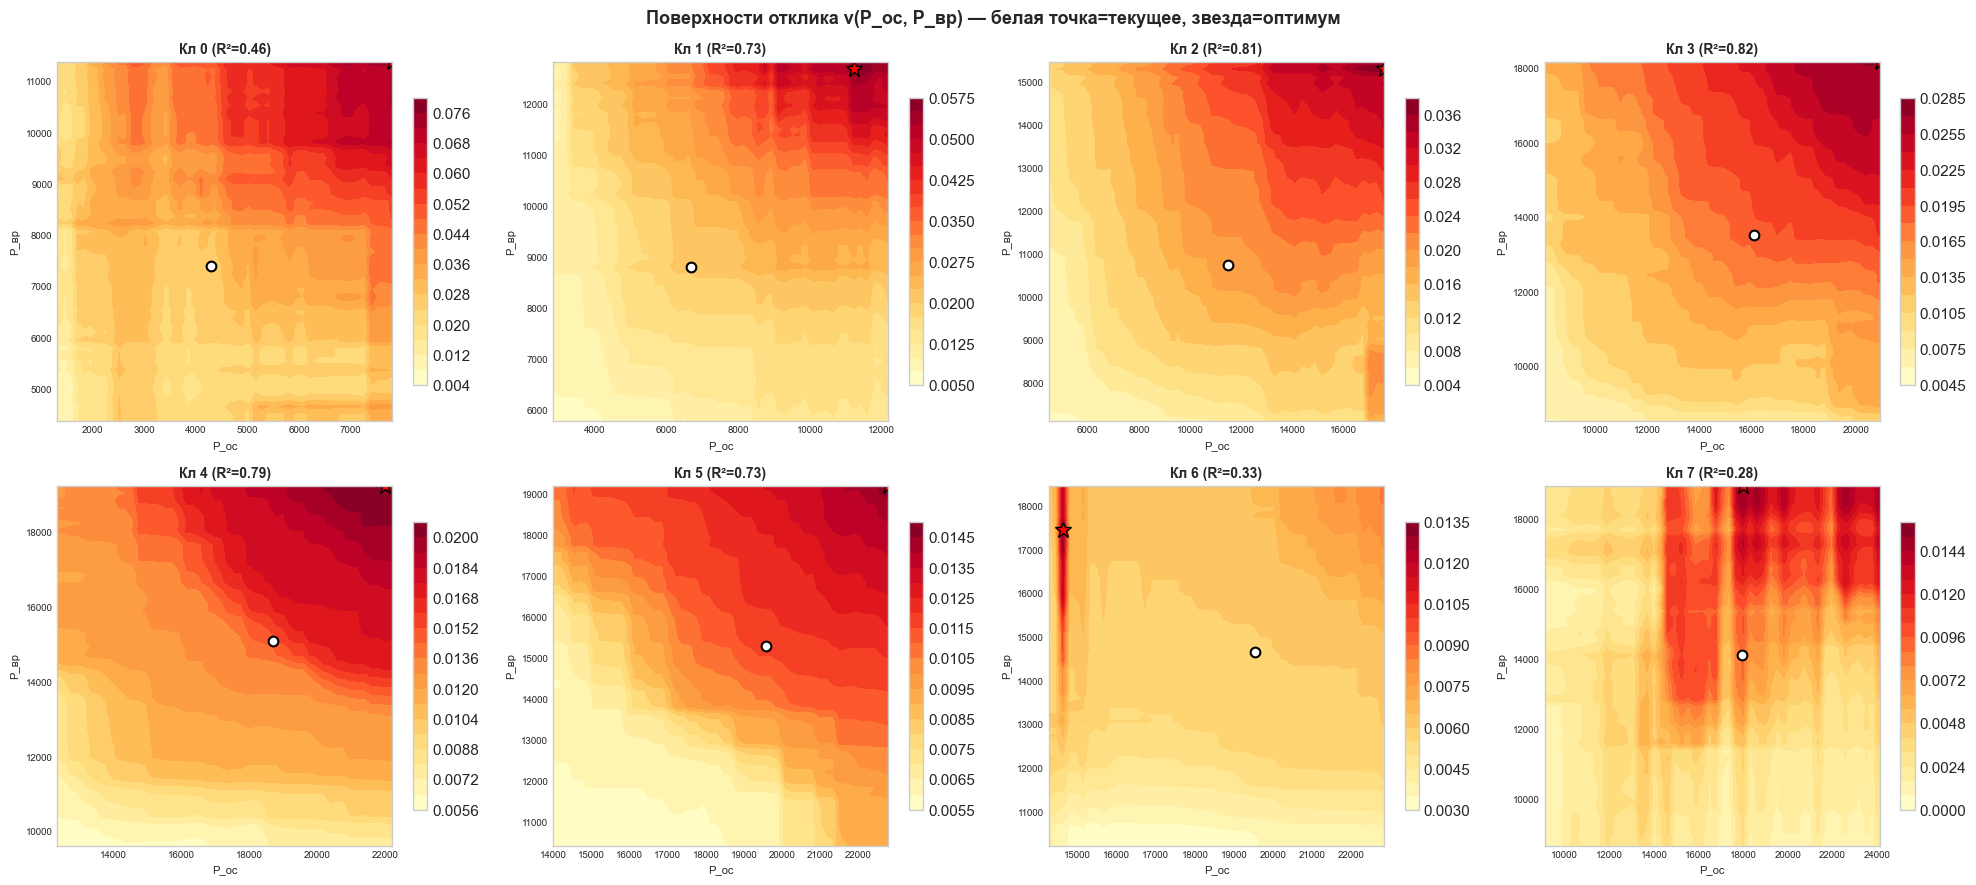

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    sub = df[df['cluster']==c]
    gbm = models[c]
    pa_lo, pa_hi = sub['pressure_axis'].quantile(0.05), sub['pressure_axis'].quantile(0.95)
    pr_lo, pr_hi = sub['pressure_rotation'].quantile(0.05), sub['pressure_rotation'].quantile(0.95)
    
    PA, PR = np.meshgrid(np.linspace(pa_lo, pa_hi, 50), np.linspace(pr_lo, pr_hi, 50))
    V = gbm.predict(np.column_stack([PA.ravel(), PR.ravel()])).reshape(PA.shape)
    
    cf = ax.contourf(PA, PR, V, levels=20, cmap='YlOrRd')
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.plot(sub['pressure_axis'].mean(), sub['pressure_rotation'].mean(),
            'wo', markersize=7, markeredgecolor='black', markeredgewidth=1.5)
    
    # Optimum
    v_grid = gbm.predict(np.column_stack([PA.ravel(), PR.ravel()]))
    best = np.argmax(v_grid)
    ax.plot(PA.ravel()[best], PR.ravel()[best], 'r*', markersize=12, markeredgecolor='black')
    
    ax.set_title(f'Кл {c} (R²={cv_scores[c]:.2f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('P_ос', fontsize=8); ax.set_ylabel('P_вр', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Поверхности отклика v(P_ос, P_вр) — белая точка=текущее, звезда=оптимум',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Scatter: P_ос vs P_вр, цвет = скорость

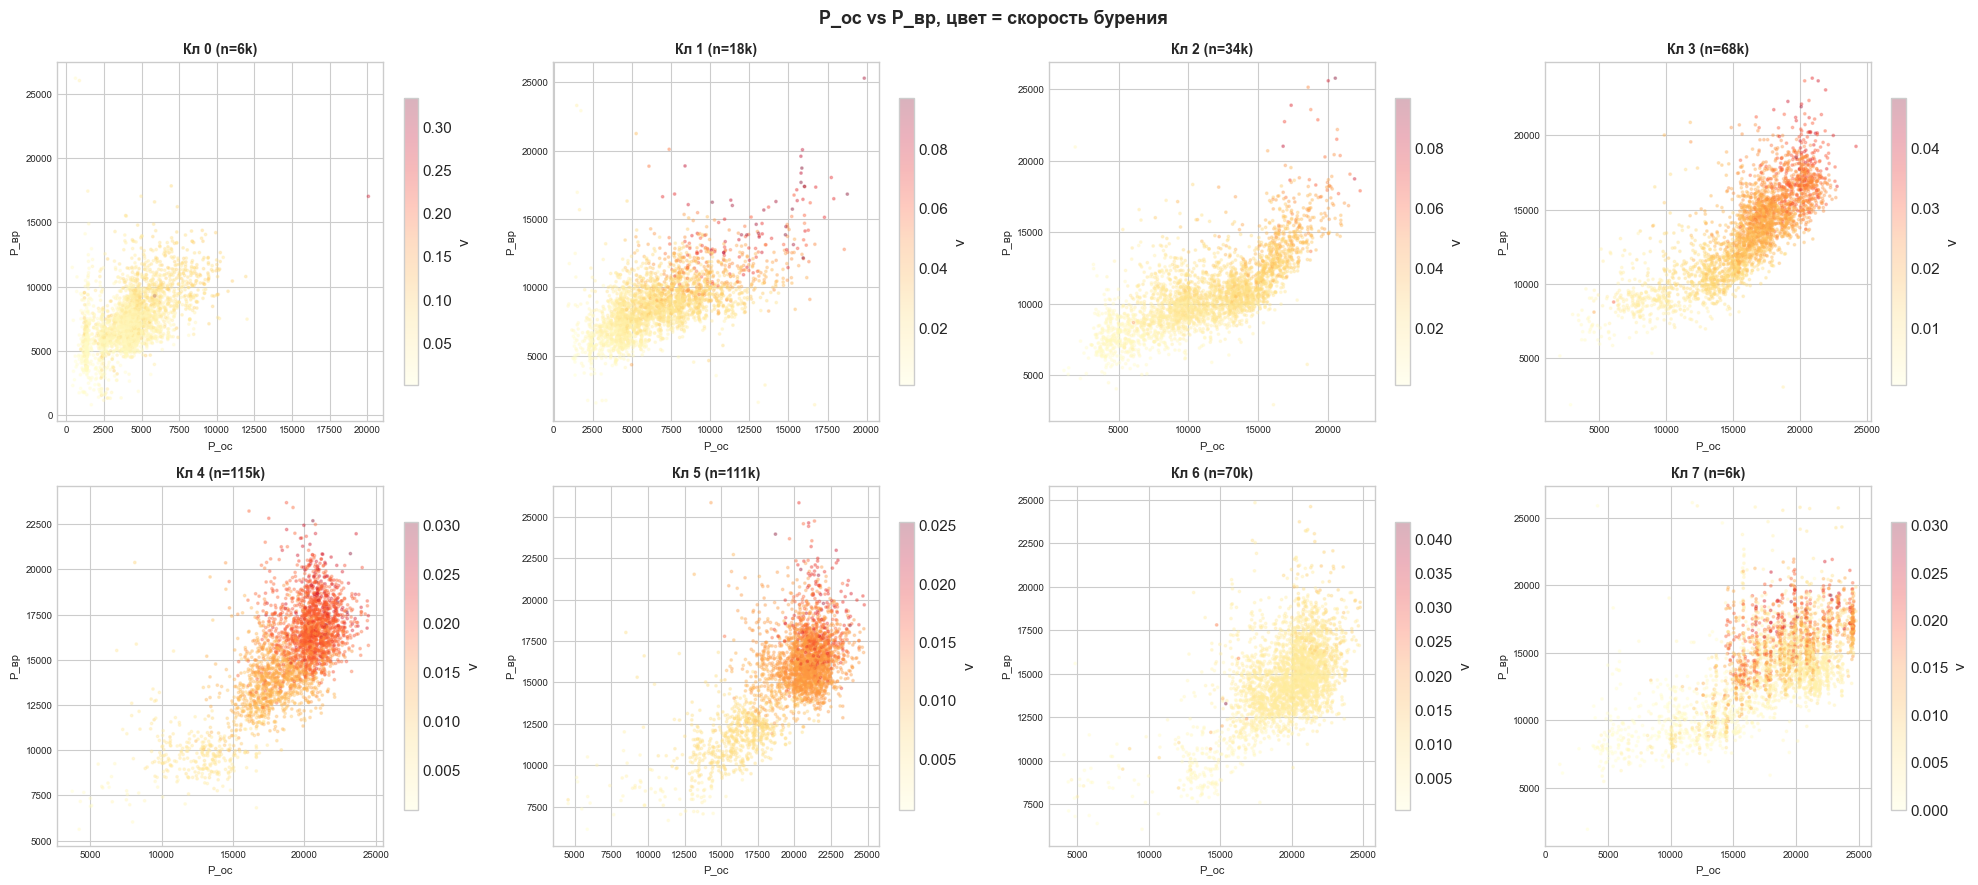

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    sub = df[df['cluster']==c]
    sample = sub.sample(min(3000, len(sub)), random_state=42)
    sc = ax.scatter(sample['pressure_axis'], sample['pressure_rotation'],
                    c=sample['speed'], s=3, alpha=0.3, cmap='YlOrRd')
    plt.colorbar(sc, ax=ax, shrink=0.8, label='v')
    ax.set_title(f'Кл {c} (n={len(sub)/1000:.0f}k)', fontsize=10, fontweight='bold')
    ax.set_xlabel('P_ос', fontsize=8); ax.set_ylabel('P_вр', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('P_ос vs P_вр, цвет = скорость бурения', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Violin: скорость по кластерам

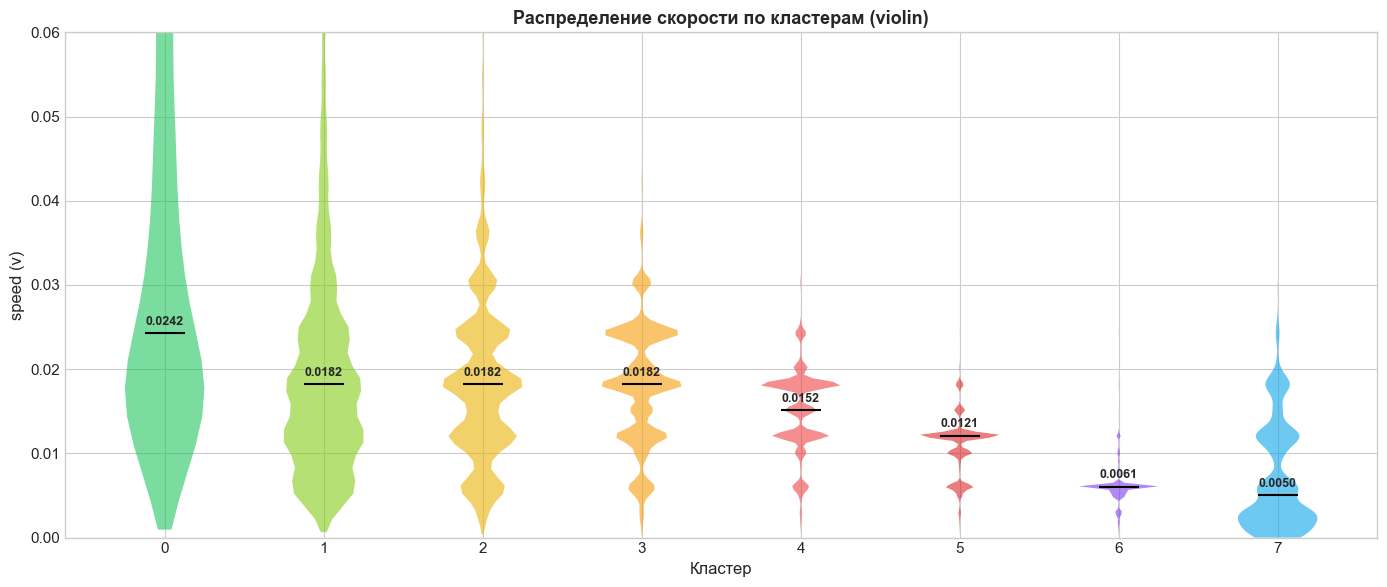

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

data = [df[df['cluster']==c]['speed'].values for c in range(N_CLUSTERS)]
parts = ax.violinplot(data, positions=range(N_CLUSTERS), showmedians=True, showextrema=False)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(COLORS[i])
    pc.set_alpha(0.6)
parts['cmedians'].set_color('black')

# Add median labels
for c in range(N_CLUSTERS):
    med = df[df['cluster']==c]['speed'].median()
    ax.text(c, med + 0.001, f'{med:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Кластер', fontsize=12)
ax.set_ylabel('speed (v)', fontsize=12)
ax.set_title('Распределение скорости по кластерам (violin)', fontsize=13, fontweight='bold')
ax.set_xticks(range(N_CLUSTERS))
ax.set_ylim(0, 0.06)
plt.tight_layout()
plt.show()

## 13. Средняя скорость по скважинам

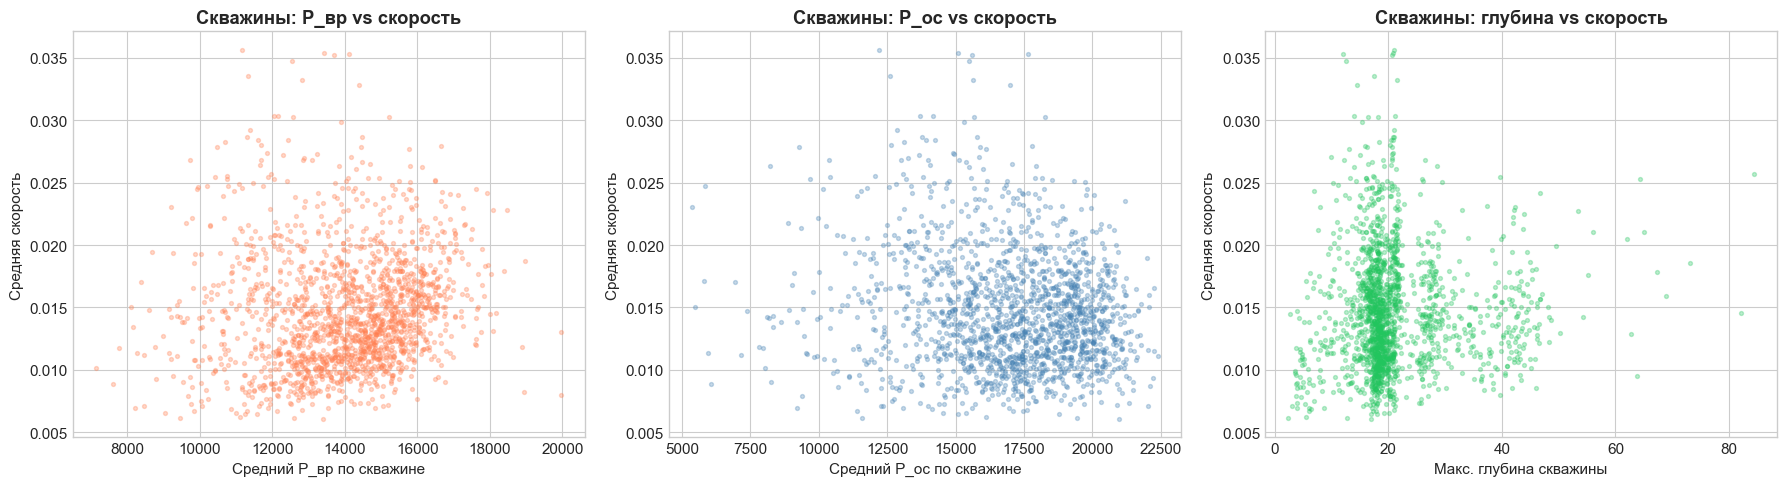

In [16]:
well_stats = df.groupby('well_id').agg(
    mean_speed=('speed', 'mean'),
    mean_pr=('pressure_rotation', 'mean'),
    mean_pa=('pressure_axis', 'mean'),
    max_depth=('depth', 'max'),
    n_records=('speed', 'count'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(well_stats['mean_pr'], well_stats['mean_speed'], s=8, alpha=0.3, color='coral')
axes[0].set_xlabel('Средний P_вр по скважине')
axes[0].set_ylabel('Средняя скорость')
axes[0].set_title('Скважины: P_вр vs скорость', fontweight='bold')

axes[1].scatter(well_stats['mean_pa'], well_stats['mean_speed'], s=8, alpha=0.3, color='steelblue')
axes[1].set_xlabel('Средний P_ос по скважине')
axes[1].set_ylabel('Средняя скорость')
axes[1].set_title('Скважины: P_ос vs скорость', fontweight='bold')

axes[2].scatter(well_stats['max_depth'], well_stats['mean_speed'], s=8, alpha=0.3, color='#22c55e')
axes[2].set_xlabel('Макс. глубина скважины')
axes[2].set_ylabel('Средняя скорость')
axes[2].set_title('Скважины: глубина vs скорость', fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Heatmap: P_ос vs P_вр → средняя скорость (кластер 3)

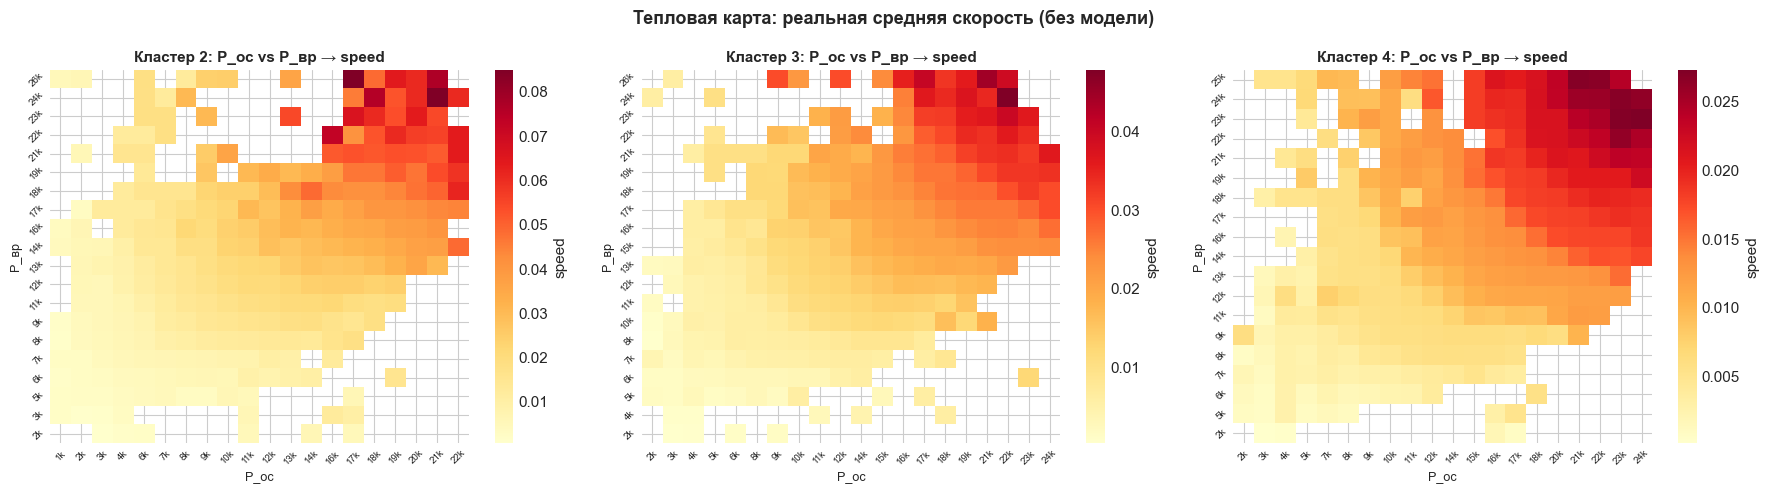

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, c in zip(axes, [2, 3, 4]):
    sub = df[df['cluster']==c].copy()
    sub['pa_bin'] = pd.cut(sub['pressure_axis'], bins=20)
    sub['pr_bin'] = pd.cut(sub['pressure_rotation'], bins=20)
    
    pivot = sub.pivot_table(values='speed', index='pr_bin', columns='pa_bin', aggfunc='mean')
    
    # Clean labels
    xlabels = [f'{x.mid/1000:.0f}k' for x in pivot.columns]
    ylabels = [f'{y.mid/1000:.0f}k' for y in pivot.index]
    
    sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'speed'},
                xticklabels=xlabels, yticklabels=ylabels)
    ax.set_title(f'Кластер {c}: P_ос vs P_вр → speed', fontsize=11, fontweight='bold')
    ax.set_xlabel('P_ос', fontsize=9)
    ax.set_ylabel('P_вр', fontsize=9)
    ax.tick_params(labelsize=7, rotation=45)
    ax.invert_yaxis()

plt.suptitle('Тепловая карта: реальная средняя скорость (без модели)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Оптимизация: текущие vs рекомендуемые давления

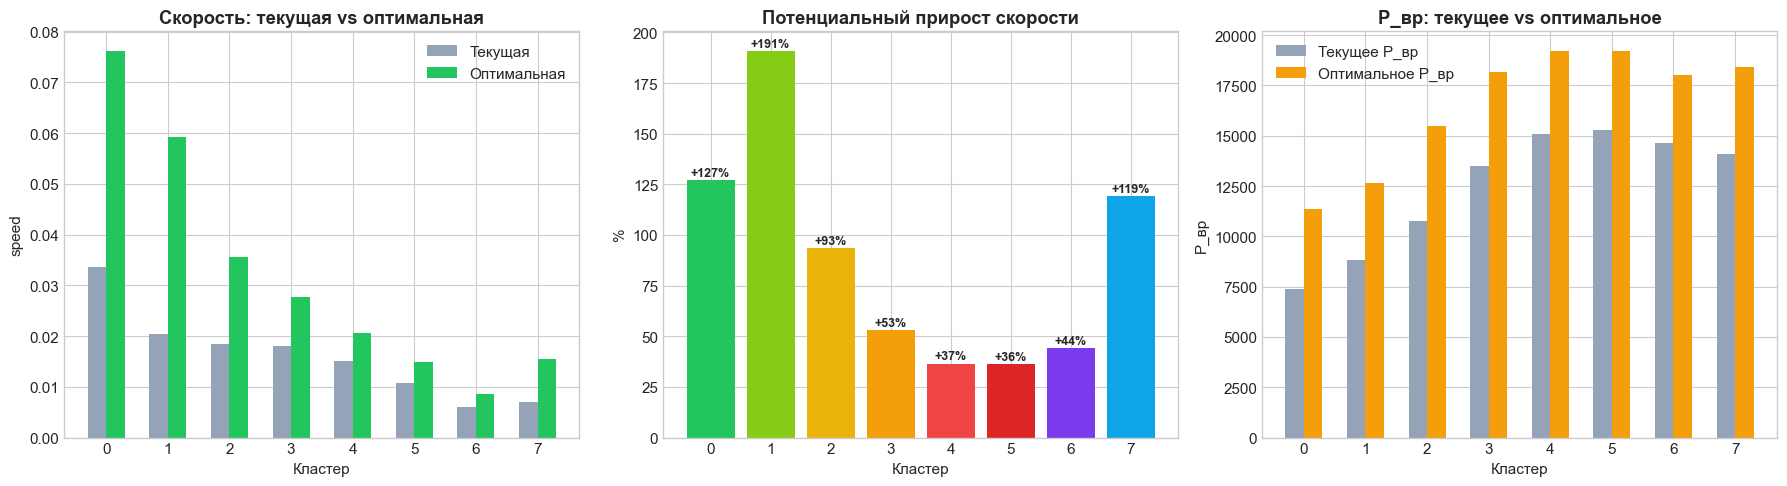

In [18]:
# Оптимизация: текущие vs рекомендуемые (best operators)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(N_CLUSTERS)

cur_v = [r['current_v'] for r in opt_results]
best_v = [r['best_v'] for r in opt_results]
best_g = [r['best_gain'] for r in opt_results]
cur_pr = [r['current_Prot'] for r in opt_results]
best_pr = [r['best_Prot'] for r in opt_results]
cur_pa = [r['current_Pax'] for r in opt_results]
best_pa = [r['best_Pax'] for r in opt_results]

axes[0].bar(x - 0.15, cur_v, 0.3, label='Текущая', color='#94a3b8')
axes[0].bar(x + 0.15, best_v, 0.3, label='Лучшие 25%', color='#22c55e')
axes[0].set_title('Скорость: текущая vs лучшие операторы', fontweight='bold')
axes[0].set_xlabel('Кластер'); axes[0].set_ylabel('speed'); axes[0].set_xticks(x); axes[0].legend()

bars = axes[1].bar(x, best_g, color=COLORS)
for bar, val in zip(bars, best_g):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'+{val:.0f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Прирост (best 25%)', fontweight='bold')
axes[1].set_xlabel('Кластер'); axes[1].set_ylabel('%'); axes[1].set_xticks(x)

w = 0.2
axes[2].bar(x - w, cur_pr, w, label='P_вр текущее', color='#94a3b8')
axes[2].bar(x, best_pr, w, label='P_вр лучших', color='#22c55e')
axes[2].bar(x + w, [(bp - cp) for bp, cp in zip(best_pa, cur_pa)], w,
            bottom=cur_pa, label='ΔP_ос лучших', color='#3b82f6', alpha=0.5)
axes[2].set_title('Давления: текущие vs лучшие', fontweight='bold')
axes[2].set_xlabel('Кластер'); axes[2].set_xticks(x); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 16. Сводная таблица результатов

In [20]:
summary = pd.DataFrame([{
    'Кластер': r['cluster'],
    'Записей': r['n_records'],
    'R²': round(r['R2_cv'], 3),
    'FI P_вр': f"{r['fi_Prot']:.0%}",
    'v текущая': round(r['current_v'], 5),
    'v лучших 25%': round(r['best_v'], 5),
    'Прирост': f"+{r['best_gain']:.1f}%",
    'P_вр тек→рек': f"{r['current_Prot']:.0f} → {r['best_Prot']:.0f}",
    'P_ос тек→рек': f"{r['current_Pax']:.0f} → {r['best_Pax']:.0f}",
} for r in opt_results]).set_index('Кластер')

summary

,Записей,R²,FI P_вр,v текущая,v оптимальная,Прирост,P_вр тек→опт
Кластер,,,,,,,
0,5900,0.459,65%,0.03356,0.07627,+127.3%,7390 → 11382
1,17877,0.733,67%,0.02039,0.05933,+191.0%,8810 → 12649
2,33721,0.805,47%,0.01843,0.03565,+93.5%,10743 → 15475
3,68219,0.816,83%,0.01805,0.02766,+53.2%,13517 → 18179
4,114911,0.791,87%,0.01509,0.02060,+36.6%,15103 → 19227
5,110575,0.732,88%,0.01085,0.01481,+36.4%,15304 → 19186
6,69689,0.332,77%,0.00601,0.00866,+44.2%,14661 → 18030
7,6308,0.278,62%,0.00706,0.01546,+119.0%,14108 → 18400
